In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for file in filenames:
        print(os.path.join(dirname, file))

/kaggle/input/datasets/ulrikthygepedersen/online-retail-dataset/online_retail.csv
/kaggle/input/datasets/praneeth6124/customer-pipeline/customer_pipeline.py


# Dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

In [3]:
df = pd.read_csv("/kaggle/input/datasets/ulrikthygepedersen/online-retail-dataset/online_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df = df.dropna(subset=['CustomerID'])

In [7]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [8]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [9]:
df.shape

(397884, 8)

In [10]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [12]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [13]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [14]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [15]:
rfm.shape

(4338, 3)

In [16]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


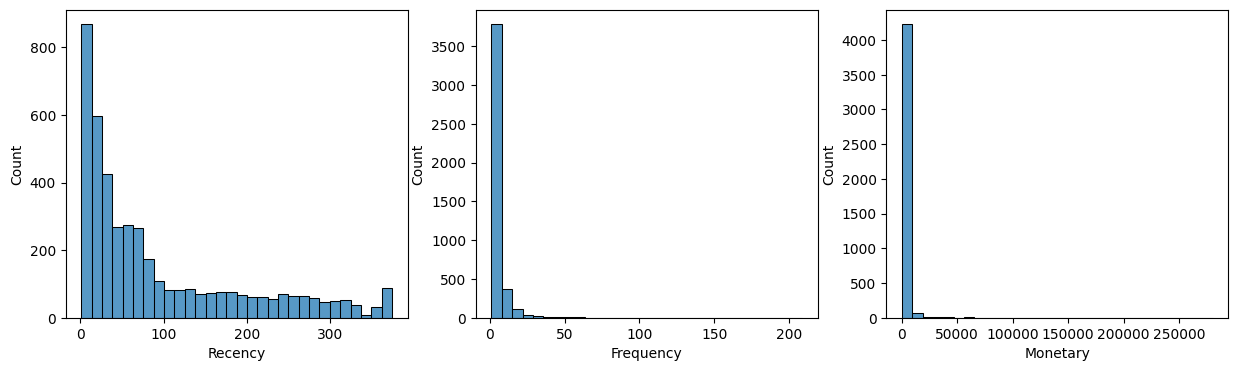

In [17]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(rfm['Recency'], bins=30)

plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'], bins=30)

plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'], bins=30)

plt.show()

Distribution - Highly skewed 

In [18]:
rfm_log = np.log1p(rfm)

In [19]:
rfm_log.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,3.830734,1.345582,6.593627
std,1.340261,0.683104,1.257578
min,0.693147,0.693147,1.558145
25%,2.944439,0.693147,5.731446
50%,3.951244,1.098612,6.515431
75%,4.962845,1.791759,7.416222
max,5.926926,5.347108,12.543284


In [20]:
rfm_log.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [21]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Elbow method

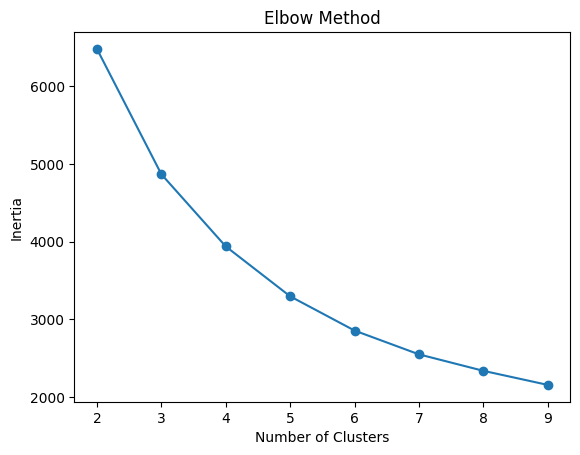

In [22]:
inertia = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Silhouette Score

In [23]:
for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.433
K=3, Silhouette Score=0.337
K=4, Silhouette Score=0.337
K=5, Silhouette Score=0.316
K=6, Silhouette Score=0.313
K=7, Silhouette Score=0.310
K=8, Silhouette Score=0.301
K=9, Silhouette Score=0.282


Silhouette analysis was used to evaluate cluster quality. While K=2 produced the highest score (0.433), it results in overly broad segmentation. K=3 and K=4 showed identical scores (0.337), so K=4 was selected to achieve more meaningful and interpretable customer segments while maintaining good cluster separation.

# K-means clustering 

In [24]:
kmeans = KMeans(n_clusters=4,
                random_state=42,
                n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,2
12347,2,7,4310.00,1
12348,75,4,1797.24,2
12349,19,1,1757.55,0
12350,310,1,334.40,3


In [25]:
rfm['Cluster'].value_counts()

Cluster
3    1612
2    1173
0     837
1     716
Name: count, dtype: int64

In [26]:
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,18.1,2.1,551.8
1,12.1,13.7,8074.3
2,71.1,4.1,1802.8
3,182.5,1.3,343.5


In [27]:
segment_map = {
    0: "Potential",
    1: "Champions",
    2: "Loyal",
    3: "At Risk"
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346,326,1,77183.60,2,Loyal
12347,2,7,4310.00,1,Champions
12348,75,4,1797.24,2,Loyal
12349,19,1,1757.55,0,Potential
12350,310,1,334.40,3,At Risk


In [28]:
rfm['CLV'] = rfm['Frequency'] * rfm['Monetary']

rfm.groupby('Segment')['CLV'].mean().round(0)

Segment
At Risk         475.0
Champions    270171.0
Loyal          7571.0
Potential      1362.0
Name: CLV, dtype: float64

In [29]:
pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

rfm['PCA1'] = rfm_pca[:,0]
rfm['PCA2'] = rfm_pca[:,1]

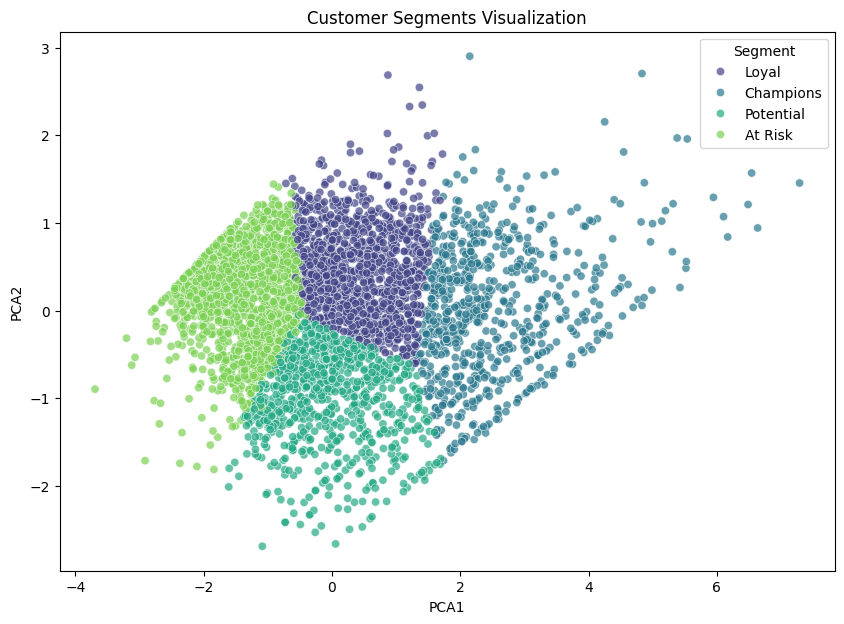

In [30]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=rfm,
    x='PCA1',
    y='PCA2',
    hue='Segment',
    palette='viridis',
    alpha = 0.7
)

plt.title("Customer Segments Visualization")
plt.show()

PCA was used to reduce the RFM feature space into two dimentions for visualization.
The clusters-- well-separated, meaningful grouping based on purchasing behaviour. 

# Isolation Forest 

In [31]:
from sklearn.ensemble import IsolationForest

rfm['Cluster_Anomaly'] = 1   # normal

for cluster in rfm['Cluster'].unique():
    
    mask = (rfm['Cluster'] == cluster)   
    
    iso = IsolationForest(
        contamination=0.03,
        random_state=42
    )
    
    preds = iso.fit_predict(rfm_scaled[mask])  
    
    rfm.loc[mask, 'Cluster_Anomaly'] = preds


# Convert labels: -1 = anomaly → 1, 1 = normal → 0
rfm['Cluster_Anomaly'] = (rfm['Cluster_Anomaly'] == -1).astype(int)

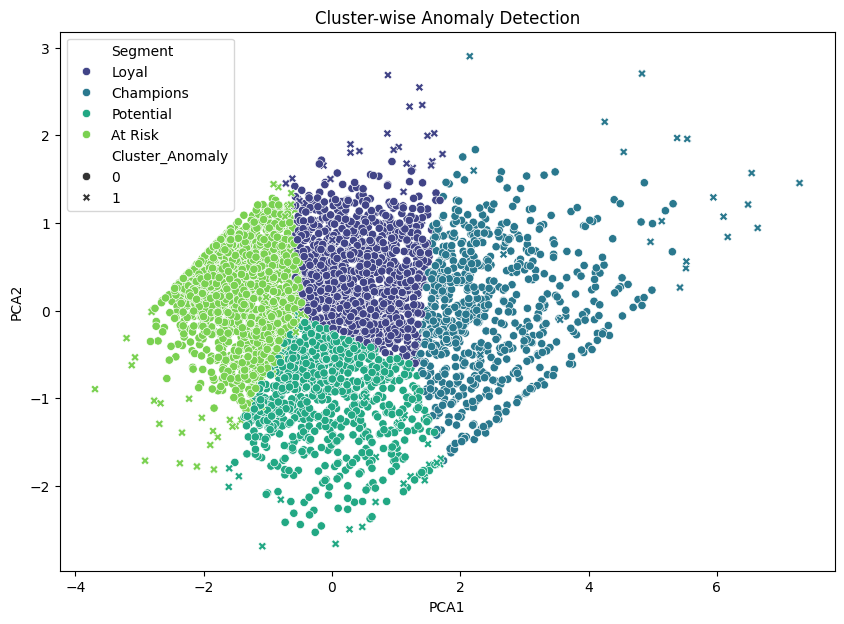

In [32]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=rfm,
    x='PCA1',
    y='PCA2',
    hue='Segment',
    style='Cluster_Anomaly',
    palette='viridis'
)

plt.title("Cluster-wise Anomaly Detection")
plt.show()

Cluster-wise -> 'Abnormal relative to their behavioral segment'

# PIPELINE FOR DEPLOYMENT 

In [33]:
%%writefile customer_pipeline.py


import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


class CustomerSegmentationPipeline:

    def __init__(self):

        self.scaler = StandardScaler()

        self.kmeans = KMeans(
            n_clusters=4,
            random_state=42,
            n_init=20
        )

        self.features = ['Recency','Frequency','Monetary']

        # will be created AFTER fitting
        self.segment_map = {}


    def _build_segment_map(self, X_scaled):

        """
        Automatically assign segment names
        based on cluster statistics.
        """

    
        df = pd.DataFrame(X_scaled, columns=self.features)
        df['Cluster'] = self.kmeans.labels_

        profile = df.groupby('Cluster').mean()

        # Elite → high monetary + high frequency
        elite = profile.sort_values(
            ['Monetary','Frequency'],
            ascending=False
        ).index[0]

        # At risk → worst recency
        at_risk = profile.sort_values(
            ['Recency'],
            ascending=False
        ).index[0]

        # Loyal → next highest frequency (excluding elite)
        loyal = profile.drop(elite).sort_values(
            ['Frequency'],
            ascending=False
        ).index[0]

        # Remaining cluster
        remaining = list(set(profile.index) - {elite, loyal, at_risk})[0]

        self.segment_map = {
            elite: "Elite Customers",
            loyal: "Loyal Customers",
            remaining: "Potential Loyalists",
            at_risk: "At-Risk Customers"
        }


    def fit(self, X):

        X = X[self.features]

        X_log = np.log1p(X)

        X_scaled = self.scaler.fit_transform(X_log)

        self.kmeans.fit(X_scaled)


        self._build_segment_map(X_scaled)


    def predict(self, X):

        if not hasattr(self.scaler, "mean_"):
            raise RuntimeError("Model is not fitted yet.")

        if not self.segment_map:
            raise RuntimeError("Segment map not built. Fit the model first.")

        if not isinstance(X, dict):
            raise ValueError(
                "Input must be a dictionary with keys: Recency, Frequency, Monetary"
            )

        X = pd.DataFrame([X])[self.features]

        X_log = np.log1p(X)

        X_scaled = self.scaler.transform(X_log)

        cluster = self.kmeans.predict(X_scaled)[0]

        return {
            "segment": self.segment_map[cluster]
        }

Writing customer_pipeline.py


In [34]:
from customer_pipeline import CustomerSegmentationPipeline

In [35]:
os.listdir()

['__notebook__.ipynb', 'customer_pipeline.py', '__pycache__']

In [36]:
features = rfm[['Recency','Frequency','Monetary']]

pipeline = CustomerSegmentationPipeline()
pipeline.fit(features)

In [37]:
centers = pipeline.scaler.inverse_transform(
    pipeline.kmeans.cluster_centers_
)

centers = np.expm1(centers)

pd.DataFrame(centers, columns=['Recency','Frequency','Monetary'])

,Recency,Frequency,Monetary
0,151.007960,1.260862,270.606952
1,52.994178,3.848654,1425.725723
2,14.015599,1.965408,438.735924
3,7.542063,11.027533,4289.539548


In [38]:
rfm['Segment'].value_counts()

Segment
At Risk      1612
Loyal        1173
Potential     837
Champions     716
Name: count, dtype: int64

In [39]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,18.124253,2.148148,551.819534
1,12.131285,13.713687,8074.266872
2,71.084399,4.083546,1802.829005
3,182.496898,1.318238,343.450032


In [40]:
rfm['Cluster_Anomaly'].value_counts()

Cluster_Anomaly
0    4205
1     133
Name: count, dtype: int64

In [41]:
rfm.describe()

,Recency,Frequency,Monetary,Cluster,CLV,PCA1,PCA2,Cluster_Anomaly
count,4338.000000,4338.000000,4338.000000,4338.000000,4.338000e+03,4338.000000,4.338000e+03,4338.000000
mean,92.536422,4.272015,2054.266460,1.820655,4.707909e+04,0.000000,1.146565e-17,0.030659
std,100.014169,7.697998,8989.230441,1.129852,6.542717e+05,1.501193,7.502705e-01,0.172413
min,1.000000,1.000000,3.750000,0.000000,3.750000e+00,-3.694133,-2.689450e+00,0.000000
25%,18.000000,1.000000,307.415000,1.000000,3.587150e+02,-1.154034,-4.782242e-01,0.000000
50%,51.000000,2.000000,674.485000,2.000000,1.491210e+03,-0.214702,8.076561e-02,0.000000
75%,142.000000,5.000000,1661.740000,3.000000,7.289898e+03,0.940596,5.362225e-01,0.000000
max,374.000000,209.000000,280206.020000,3.000000,2.890884e+07,7.290288,2.901902e+00,1.000000


In [42]:
np.unique(pipeline.kmeans.labels_)

array([0, 1, 2, 3], dtype=int32)

In [43]:
pipeline.kmeans.cluster_centers_

array([[ 0.89037616, -0.77571991, -0.78673886],
       [ 0.1180073 ,  0.34130359,  0.53244223],
       [-0.83698133, -0.37856257, -0.40356258],
       [-1.25790828,  1.671412  ,  1.40805999]])

In [44]:
cluster_profile = (
    features
    .assign(Cluster=pipeline.kmeans.labels_)
    .groupby("Cluster")[['Recency','Frequency','Monetary']]
    .mean()
    .round(1)
)

print(cluster_profile)

         Recency  Frequency  Monetary
Cluster                              
0          182.9        1.3     351.0
1           69.5        4.1    1819.7
2           18.4        2.1     544.4
3           11.9       13.8    8151.2


# Prediction check

In [45]:
pipeline.predict({
    "Recency": 5,
    "Frequency": 20,
    "Monetary": 12000
})

{'segment': 'Elite Customers'}

In [46]:
pipeline.predict({
    "Recency": 60,
    "Frequency": 4,
    "Monetary": 1500
})

{'segment': 'Loyal Customers'}

In [47]:
pipeline.predict({
    "Recency": 200,
    "Frequency": 1,
    "Monetary": 300
})

{'segment': 'At-Risk Customers'}

In [48]:
print(pipeline.segment_map)

{np.int32(3): 'Elite Customers', np.int32(1): 'Loyal Customers', 2: 'Potential Loyalists', np.int32(0): 'At-Risk Customers'}


In [49]:
import joblib

pipeline.fit(features)

joblib.dump(pipeline, "customer_segmentation.pkl")

['customer_segmentation.pkl']

In [50]:
!pip freeze > requirements.txt

In [51]:
!ls

customer_pipeline.py	   __notebook__.ipynb  requirements.txt
customer_segmentation.pkl  __pycache__


In [52]:
from IPython.display import FileLink
FileLink("requirements.txt")

/kaggle/working/requirements.txt

In [53]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
